# Exercise 2 — Overlapping Data (Pocket Algorithm)

Runnable code for the *Perceptron* deliverable. The **same** perceptron from
`perceptron.py` is reused unchanged on two heavily overlapping clouds. Because the
data is not linearly separable the loop never stops updating, so we track the
**final** weights (whatever the last epoch holds) and the **pocket** weights (the
best-so-far on full-dataset accuracy).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from perceptron import Perceptron

%matplotlib inline

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
COLORS = {0: "#1f77b4", 1: "#d62728"}


def build_data(rng):
    """Two overlapping Gaussian clouds, 1000 samples per class."""
    X0 = rng.multivariate_normal([3.0, 3.0], [[1.5, 0.0], [0.0, 1.5]], size=1000)
    X1 = rng.multivariate_normal([4.0, 4.0], [[1.5, 0.0], [0.0, 1.5]], size=1000)
    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(1000, dtype=int), np.ones(1000, dtype=int)])
    return X, y

## A — Generate the data

Class 0 $\sim \mathcal{N}([3,3], 1.5 I)$ and Class 1 $\sim \mathcal{N}([4,4], 1.5 I)$. The means are now only ~1.4 units apart while the standard deviation is
~1.2, so the clouds overlap heavily and no straight line separates them.


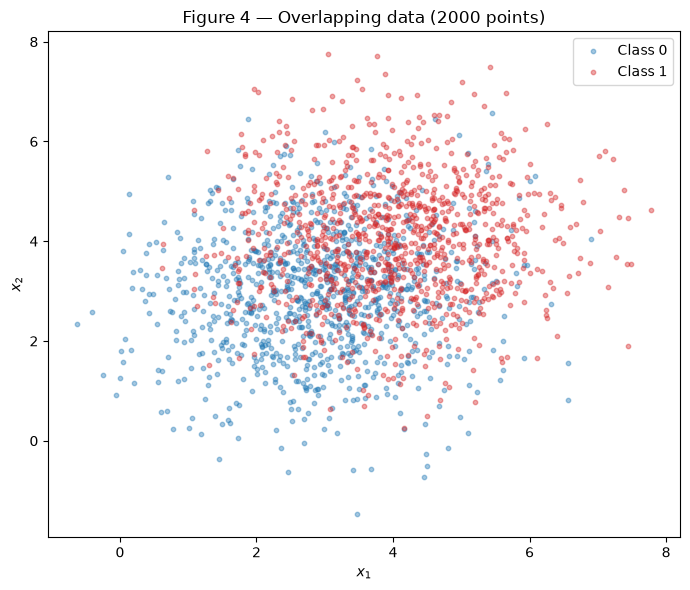

In [2]:
rng = np.random.default_rng(42)
X, y = build_data(rng)

fig, ax = plt.subplots(figsize=(7, 6))
for k in (0, 1):
    ax.scatter(X[y == k, 0], X[y == k, 1], s=10, alpha=0.4,
               color=COLORS[k], label=f"Class {k}")
ax.set_title("Figure 4 — Overlapping data (2000 points)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_overlap_data.png", dpi=150)
plt.show()

## B — Train, keeping the best weights (pocket)

Reuse the Exercise 1 implementation unchanged, with $\eta = 0.01$ and the 100-epoch
cap, now with `pocket=True`.

In [3]:
model = Perceptron(n_features=2, rng=rng, lr=0.01)
history, best = model.train(X, y, max_epochs=100, pocket=True)

final_w, final_b = model.w, model.b
final_acc = model.accuracy(X, y)
pocket_w, pocket_b, pocket_acc, pocket_epoch = (
    best["w"], best["b"], best["acc"], best["epoch"])

print("FINAL  weights:")
print(f"  w = {final_w},  b = {final_b:.4f},  accuracy = {final_acc:.4f}")
print("POCKET weights (best-so-far):")
print(f"  w = {pocket_w},  b = {pocket_b:.4f},  accuracy = {pocket_acc:.4f}")
print(f"  best accuracy first reached at epoch {pocket_epoch}")

FINAL  weights:
  w = [0.03605737 0.04942081],  b = -0.0400,  accuracy = 0.5005
POCKET weights (best-so-far):
  w = [0.00684108 0.00662048],  b = -0.0500,  accuracy = 0.7285
  best accuracy first reached at epoch 18


## C — Figures

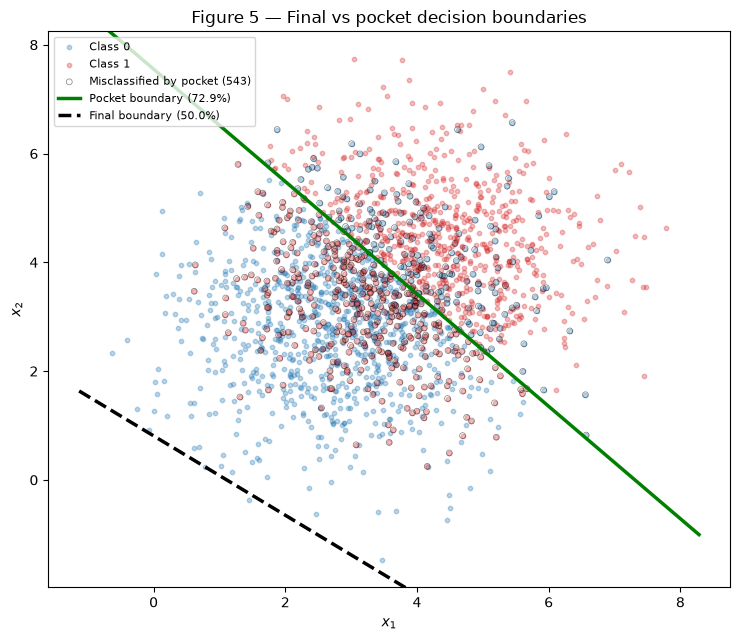

In [4]:
def boundary_xy(w, b, xr):
    return -(w[0] * xr + b) / w[1]


fig, ax = plt.subplots(figsize=(7.5, 6.5))
for k in (0, 1):
    ax.scatter(X[y == k, 0], X[y == k, 1], s=10, alpha=0.3,
               color=COLORS[k], label=f"Class {k}")

# mark points misclassified by the pocket weights
pocket_pred = (X @ pocket_w + pocket_b >= 0).astype(int)
mis = pocket_pred != y
ax.scatter(X[mis, 0], X[mis, 1], s=18, facecolors="none",
           edgecolors="black", linewidths=0.5, alpha=0.5,
           label=f"Misclassified by pocket ({mis.sum()})")

xr = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
ax.plot(xr, boundary_xy(pocket_w, pocket_b, xr), "g-", lw=2.5,
        label=f"Pocket boundary ({pocket_acc:.1%})")
ax.plot(xr, boundary_xy(final_w, final_b, xr), "k--", lw=2.5,
        label=f"Final boundary ({final_acc:.1%})")
ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
ax.set_title("Figure 5 — Final vs pocket decision boundaries")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_boundaries.png", dpi=150)
plt.show()

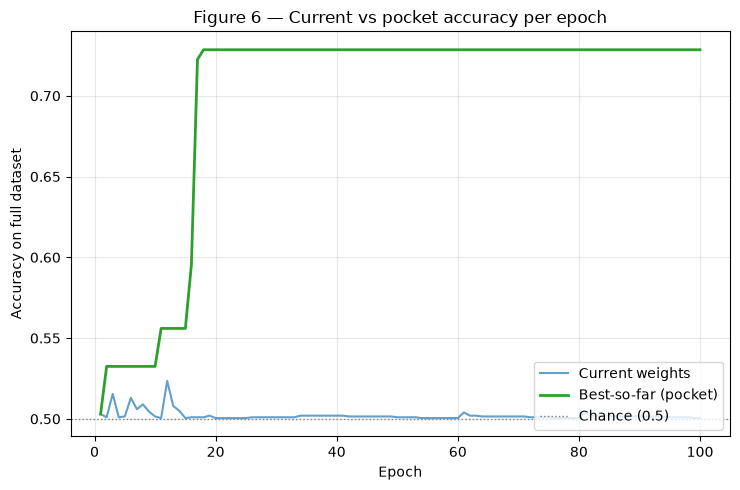

In [5]:
epochs = len(history["acc"])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(range(1, epochs + 1), history["acc"], color="#1f77b4",
        alpha=0.7, label="Current weights")
ax.plot(range(1, epochs + 1), history["best_acc"], color="#2ca02c",
        lw=2, label="Best-so-far (pocket)")
ax.axhline(0.5, color="grey", ls=":", lw=1, label="Chance (0.5)")
ax.set_title("Figure 6 — Current vs pocket accuracy per epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy on full dataset")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_pocket_curves.png", dpi=150)
plt.show()